Import Libraries


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

Generate a random Dataset

In [2]:
np.random.seed(42)

samples=600

battery_temperature=np.random.uniform(15,45,samples)
charge_cycles=np.random.uniform(200,1800,samples)

distance=((battery_temperature-30)**2)/36+((charge_cycles-1000)**2)/160000

battery_health=(distance<=1).astype(int)

noise=np.random.choice(samples,int(samples*0.05),replace=False)
battery_health[noise]=1-battery_health[noise]

dataset=pd.DataFrame({
    "Battery_Temperature":np.round(battery_temperature,2),
    "Charge_Cycles":charge_cycles.astype(int),
    "Battery_Health":battery_health
})

dataset.head()

,Battery_Temperature,Charge_Cycles,Battery_Health
0,26.24,470,0
1,43.52,645,0
2,36.96,483,0
3,32.96,341,0
4,19.68,393,0


Save the generated Dataset

In [3]:
dataset.to_csv("ev_battery_health.csv",index=False)
print("Dataset Saved Successfully")
print(dataset.shape)

Dataset Saved Successfully
(600, 3)


Visualize Dataset

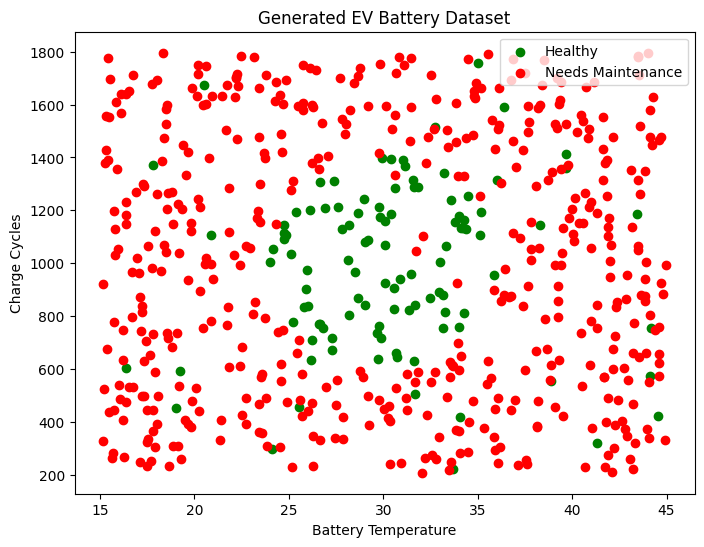

In [4]:
plt.figure(figsize=(8,6))

healthy=dataset[dataset["Battery_Health"]==1]
bad=dataset[dataset["Battery_Health"]==0]

plt.scatter(
    healthy["Battery_Temperature"],
    healthy["Charge_Cycles"],
    color="green",
    label="Healthy"
)
plt.scatter(
    bad["Battery_Temperature"],
    bad["Charge_Cycles"],
    color="red",
    label="Needs Maintenance"
)
plt.xlabel("Battery Temperature")
plt.ylabel("Charge Cycles")
plt.title("Generated EV Battery Dataset")
plt.legend()
plt.show()

First, we separate the dataset into input features and the output label.

x contains the information that the SVM will use to make predictions. These are the two features:

Battery Temperature
Charge Cycles
The battery health is either:

1 → Healthy
0 → Needs Maintenance

This is what the SVM tries to predict.

In [6]:
x=dataset[["Battery_Temperature","Charge_Cycles"]]
y=dataset["Battery_Health"]
xtrain,xtest,ytrain,ytest=train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

Training the SVM

In [7]:
model=SVC(
    kernel="rbf",
    C=10,
    gamma="scale"
)
model.fit(xtrain,ytrain)

SVC(C=10)

Making Predictions


In [8]:
prediction=model.predict(xtest)

Accuracy

Calculates the accuracy of the model by comparing the predicted values with the actual test values.

In [9]:
accuracy=accuracy_score(ytest,prediction)
print("Accuracy :",accuracy)

Accuracy : 0.8333333333333334


Classification Report

Displays performance metrics such as precision, recall, F1-score, and support to evaluate the model in detail.

In [10]:
print(classification_report(ytest,prediction))

              precision    recall  f1-score   support

           0       0.83      1.00      0.91       100
           1       0.00      0.00      0.00        20

    accuracy                           0.83       120
   macro avg       0.42      0.50      0.45       120
weighted avg       0.69      0.83      0.76       120



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Confusion matrix


In [11]:
print(confusion_matrix(ytest,prediction))

[[100   0]
 [ 20   0]]


Visualize Decision Boundary

Plots the SVM decision boundary along with the dataset to visualize how the model separates the two classes.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


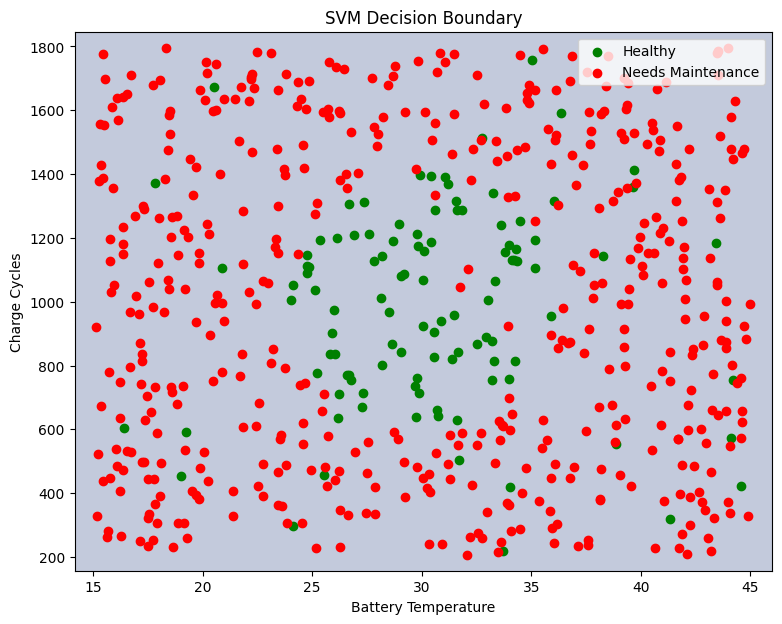

In [12]:
x1=np.linspace(
    dataset["Battery_Temperature"].min()-1,
    dataset["Battery_Temperature"].max()+1,
    300
)
x2=np.linspace(
    dataset["Charge_Cycles"].min()-50,
    dataset["Charge_Cycles"].max()+50,
    300
)
xx,yy=np.meshgrid(x1,x2)
z=model.predict(np.c_[xx.ravel(),yy.ravel()])
z=z.reshape(xx.shape)

plt.figure(figsize=(9,7))
plt.contourf(xx,yy,z,alpha=0.3)
plt.scatter(
    healthy["Battery_Temperature"],
    healthy["Charge_Cycles"],
    color="green",
    label="Healthy"
)
plt.scatter(
    bad["Battery_Temperature"],
    bad["Charge_Cycles"],
    color="red",
    label="Needs Maintenance"
)
plt.xlabel("Battery Temperature")
plt.ylabel("Charge Cycles")
plt.title("SVM Decision Boundary")
plt.legend()

plt.show()